In [1]:
"""
This notebook is for taking FITS files saved from the evaluate cli and analyzing the estimator's performance.
"""
import os
os.environ['XLA_FLAGS'] = '--xla_gpu_strict_conv_algorithm_picker=false'

import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib as mpl
from astropy.io import fits
import json
import subprocess
import warnings
warnings.filterwarnings('ignore')

import jax
jax.clear_caches()

sys.path.append('/home/adfield/ShearNet/')
from shearnet.cli.evaluate import load_config, create_parser, initialize_model

# ANSI color codes
BOLD = '\033[1m'
YELLOW = '\033[93m'
CYAN = '\033[96m'
GREEN = '\033[92m'
RED = '\033[91m'
END = '\033[0m'

# GPU diagnostics
print(f"JAX devices: {jax.devices()}")
print(f"Default backend: {jax.default_backend()}")
try:
    result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
    print(result.stdout[:500])
except:
    print("nvidia-smi not available")

# Input your FITS file path here
path = '/home/adfield/ShearNet/plots/second_validation_test_3_params/evaluation_catalog.fits'

JAX devices: [CudaDevice(id=0)]
Default backend: gpu
Sun Feb  1 06:01:37 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.133.20             Driver Version: 570.133.20     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|       


In [2]:
def load_eval_fits(filepath):
    """
    Load and unpack a ShearNet evaluation FITS file.

    Parameters
    ----------
    filepath : str
        Path to the FITS file (catalog-only or full).

    Returns
    -------
    dict with keys:
        'header'  : dict - primary header key/value pairs
        'catalog' : dict - every catalog column as a numpy array, keyed by column name
        'images'  : dict or None
                        If the file contains images:
                            'clean'  : (N, H, W) true galaxy images
                            'galaxy' : (N, H, W) observed (PSF-convolved + noise) images
                            'psf'    : (N, H, W) PSF images
                        None if catalog-only file.
    """
    hdul = fits.open(filepath)

    # Primary header
    header = dict(hdul[0].header)

    # Catalog - every column into a plain dict
    catalog = {}
    for col in hdul['CATALOG'].columns.names:
        catalog[col] = np.array(hdul['CATALOG'].data[col])

    # Images (only present in the full FITS)
    images = None
    if header.get('HASIMG', False):
        images = {
            'clean':  np.array(hdul['CLEAN_IMAGES'].data),
            'galaxy': np.array(hdul['GALAXY_IMAGES'].data),
            'psf':    np.array(hdul['PSF_IMAGES'].data),
        }

    hdul.close()

    return {
        'header':  header,
        'catalog': catalog,
        'images':  images,
    }

In [3]:
def calculate_multiplicative_bias_from_single_fits(data,
                                                    method='nn',
                                                    Njack=20,
                                                    save_path="./"):
    """
    Calculate multiplicative (m) and additive (c) bias from a ShearNet evaluation FITS.

    Response matrices are taken from the base (unsheared) dataset - R is a property
    of the estimator on each galaxy, independent of the applied shear.

    Args:
        data      : dict from load_eval_fits().
        method    : 'nn' or 'ngmix' - which method's predictions/responses to use.
        Njack     : Number of jackknife samples.
        save_path : Directory in which to write m_c_biases.json.

    Returns:
        dict with keys m1, m1_err, c1, c1_err, m2, m2_err, c2, c2_err,
        R11, R11_err, R12, R12_err, R21, R21_err, R22, R22_err.
    """
    catalog = data['catalog']
    header  = data['header']

    true_shear_step = header['SHRSTEP']
    n_gal           = len(catalog['ID'])
    M               = 'NN' if method == 'nn' else 'NGMIX'

    print(f"\n{BOLD}{'='*70}")
    print(f"CALCULATING MULTIPLICATIVE BIAS FROM FITS ({method.upper()})")
    print(f"{'='*70}{END}")
    print(f"Shear step: ±{true_shear_step}")
    print(f"Jackknife samples: {Njack}")
    print(f"Number of galaxies: {n_gal}")

    # ========== Predictions from bias datasets ==========
    e1_g1_pos = catalog[f'G1_POS_{M}_G1']
    e1_g1_neg = catalog[f'G1_NEG_{M}_G1']
    e2_g2_pos = catalog[f'G2_POS_{M}_G2']
    e2_g2_neg = catalog[f'G2_NEG_{M}_G2']

    # ========== Per-galaxy response from base dataset ==========
    R_11   = catalog[f'{M}_R11']
    R_12   = catalog[f'{M}_R12']
    R_21   = catalog[f'{M}_R21']
    R_22   = catalog[f'{M}_R22']
    flags  = catalog['FLAGS']

    # Bit 1 = invalid response matrix
    valid_response = (flags & 2) == 0

    print(f"\n{CYAN}Using per-galaxy response from base dataset{END}")

    # ========== Validity masks ==========
    mask_g1 = (
        valid_response &
        np.isfinite(e1_g1_pos) & np.isfinite(e1_g1_neg) &
        np.isfinite(R_11) & (R_11 != 0)
    )
    mask_g2 = (
        valid_response &
        np.isfinite(e2_g2_pos) & np.isfinite(e2_g2_neg) &
        np.isfinite(R_22) & (R_22 != 0)
    )

    print(f"  Valid galaxies for g1: {np.sum(mask_g1)}/{n_gal}")
    print(f"  Valid galaxies for g2: {np.sum(mask_g2)}/{n_gal}")

    # ========== Response matrix statistics ==========
    def jackknife_estimate(values):
        """Jackknife mean and error for a simple-mean statistic."""
        n = len(values)
        chunks = np.array_split(np.arange(n), Njack)
        jack_values = []
        for chunk in chunks:
            mask_j = np.ones(n, dtype=bool)
            mask_j[chunk] = False
            jack_values.append(np.mean(values[mask_j]))
        jack_values = np.array(jack_values)
        mean = np.mean(jack_values)
        err  = np.sqrt((Njack - 1) / Njack * np.sum((jack_values - mean)**2))
        return mean, err

    R11_mean, R11_err = jackknife_estimate(R_11[valid_response])
    R12_mean, R12_err = jackknife_estimate(R_12[valid_response])
    R21_mean, R21_err = jackknife_estimate(R_21[valid_response])
    R22_mean, R22_err = jackknife_estimate(R_22[valid_response])

    print(f"\n{CYAN}Response Matrix (base dataset):{END}")
    print(f"  R₁₁ = {R11_mean:.6f} ± {R11_err:.6f}")
    print(f"  R₁₂ = {R12_mean:.6f} ± {R12_err:.6f}")
    print(f"  R₂₁ = {R21_mean:.6f} ± {R21_err:.6f}")
    print(f"  R₂₂ = {R22_mean:.6f} ± {R22_err:.6f}")
    print(f"  Valid galaxies: {np.sum(valid_response)}/{n_gal}")

    # ========== Per-galaxy shear estimates ==========
    # Same galaxy in pos and neg - intrinsic ellipticity cancels in the difference.
    R11_filt = R_11[mask_g1]
    R22_filt = R_22[mask_g2]

    gamma1_per = (e1_g1_pos[mask_g1] - e1_g1_neg[mask_g1]) / (2.0 * R11_filt)
    gamma2_per = (e2_g2_pos[mask_g2] - e2_g2_neg[mask_g2]) / (2.0 * R22_filt)

    # ========== Multiplicative bias with jackknife ==========
    print(f"\n{BOLD}{CYAN}Calculating bias with jackknife...{END}")

    # m1
    n_g1   = len(gamma1_per)
    chunks = np.array_split(np.arange(n_g1), Njack)
    m1_jack = []
    for chunk in chunks:
        mask_j = np.ones(n_g1, dtype=bool)
        mask_j[chunk] = False
        m1_jack.append(np.mean(gamma1_per[mask_j]) / true_shear_step - 1)

    m1_jack = np.array(m1_jack)
    m1      = np.mean(m1_jack)
    m1_err  = np.sqrt((Njack - 1) / Njack * np.sum((m1_jack - m1)**2))

    # m2
    n_g2   = len(gamma2_per)
    chunks = np.array_split(np.arange(n_g2), Njack)
    m2_jack = []
    for chunk in chunks:
        mask_j = np.ones(n_g2, dtype=bool)
        mask_j[chunk] = False
        m2_jack.append(np.mean(gamma2_per[mask_j]) / true_shear_step - 1)

    m2_jack = np.array(m2_jack)
    m2      = np.mean(m2_jack)
    m2_err  = np.sqrt((Njack - 1) / Njack * np.sum((m2_jack - m2)**2))

    # ========== Additive bias ==========
    # c = (⟨γ_pos⟩ + ⟨γ_neg⟩) / 2 - simple mean of per-galaxy values.
    c1_per = 0.5 * (e1_g1_pos[mask_g1] / R11_filt + e1_g1_neg[mask_g1] / R11_filt)
    c1, c1_err = jackknife_estimate(c1_per)

    c2_per = 0.5 * (e2_g2_pos[mask_g2] / R22_filt + e2_g2_neg[mask_g2] / R22_filt)
    c2, c2_err = jackknife_estimate(c2_per)

    # ========== Final Results ==========
    print(f"\n{BOLD}{'='*70}")
    print("BIAS CALIBRATION RESULTS WITH JACKKNIFE ERRORS")
    print(f"{'='*70}{END}")
    print(f"\n{BOLD}{YELLOW}Component 1:{END}")
    print(f"{BOLD}  m₁ = {m1:+.6f} ± {m1_err:.6f}  ({m1*100:+.2f}% ± {m1_err*100:.2f}%){END}")
    print(f"{BOLD}  c₁ = {c1:+.6f} ± {c1_err:.6f}{END}")
    print(f"\n{BOLD}{YELLOW}Component 2:{END}")
    print(f"{BOLD}  m₂ = {m2:+.6f} ± {m2_err:.6f}  ({m2*100:+.2f}% ± {m2_err*100:.2f}%){END}")
    print(f"{BOLD}  c₂ = {c2:+.6f} ± {c2_err:.6f}{END}")
    print(f"{BOLD}{'='*70}{END}\n")

    output_dict = {
        'm1': m1, 'm1_err': m1_err,
        'c1': c1, 'c1_err': c1_err,
        'm2': m2, 'm2_err': m2_err,
        'c2': c2, 'c2_err': c2_err,
        'R11': R11_mean, 'R11_err': R11_err,
        'R12': R12_mean, 'R12_err': R12_err,
        'R21': R21_mean, 'R21_err': R21_err,
        'R22': R22_mean, 'R22_err': R22_err,
    }

    # ========== Save ==========
    outpath = os.path.join(save_path, f'{method}_m_c_biases.json')

    class NumpyEncoder(json.JSONEncoder):
        def default(self, obj):
            if isinstance(obj, np.generic):
                return obj.item()
            return super().default(obj)

    with open(outpath, "w") as f:
        json.dump(output_dict, f, indent=2, cls=NumpyEncoder)

    return output_dict

In [4]:
data = load_eval_fits(path)
cat  = data['catalog']

if np.all(cat['TRUE_SIGMA'] == 0):
    cat['TRUE_SIGMA']  = np.full(len(cat['TRUE_SIGMA']),  0.5)
if np.all(cat['TRUE_FLUX'] == 0):
    cat['TRUE_FLUX']   = np.full(len(cat['TRUE_FLUX']),   12258.97)
if np.all(cat['T_GAL'] == 0):
    cat['T_GAL']       = np.full(len(cat['T_GAL']),       2 * (0.5**2))
if np.all(cat['SIZE_RATIO'] == 0):
    cat['SIZE_RATIO']  = cat['T_GAL'] / cat['PSF_T']

shear_bias_nn = calculate_multiplicative_bias_from_single_fits(
    data=data,
    method='nn',
    save_path=os.path.dirname(path)
)
shear_bias_ngmix = calculate_multiplicative_bias_from_single_fits(
    data=data,
    method='ngmix',
    save_path=os.path.dirname(path)
)


CALCULATING MULTIPLICATIVE BIAS FROM FITS (NN)
Shear step: ±0.02
Jackknife samples: 20
Number of galaxies: 30000

Using per-galaxy response from base dataset
  Valid galaxies for g1: 30000/30000
  Valid galaxies for g2: 30000/30000

Response Matrix (base dataset):
  R₁₁ = 1.048189 ± 0.001567
  R₁₂ = 0.030614 ± 0.001574
  R₂₁ = 0.017683 ± 0.001480
  R₂₂ = 1.004195 ± 0.001799
  Valid galaxies: 30000/30000

Calculating bias with jackknife...

BIAS CALIBRATION RESULTS WITH JACKKNIFE ERRORS

Component 1:
  m₁ = -0.314238 ± 0.264681  (-31.42% ± 26.47%)
  c₁ = +0.017986 ± 0.042649

Component 2:
  m₂ = +0.255379 ± 0.227398  (+25.54% ± 22.74%)
  c₂ = +0.305557 ± 0.295290


CALCULATING MULTIPLICATIVE BIAS FROM FITS (NGMIX)
Shear step: ±0.02
Jackknife samples: 20
Number of galaxies: 30000

Using per-galaxy response from base dataset
  Valid galaxies for g1: 30000/30000
  Valid galaxies for g2: 30000/30000

Response Matrix (base dataset):
  R₁₁ = 0.901412 ± 0.001842
  R₁₂ = -0.009895 ± 0.001868
 

[WARNING] number of points in bin 0: 0  didn't pass min count = 20
[WARNING] number of points in bin 1: 0  didn't pass min count = 20
[WARNING] number of points in bin 2: 0  didn't pass min count = 20
[WARNING] number of points in bin 3: 0  didn't pass min count = 20
[WARNING] number of points in bin 4: 0  didn't pass min count = 20
[WARNING] number of points in bin 5: 0  didn't pass min count = 20
[WARNING] number of points in bin 6: 0  didn't pass min count = 20
[WARNING] number of points in bin 7: 0  didn't pass min count = 20
[WARNING] number of points in bin 8: 0  didn't pass min count = 20
[WARNING] number of points in bin 0: 0  didn't pass min count = 20
[WARNING] number of points in bin 1: 0  didn't pass min count = 20
[WARNING] number of points in bin 2: 0  didn't pass min count = 20
[WARNING] number of points in bin 3: 0  didn't pass min count = 20
[WARNING] number of points in bin 4: 0  didn't pass min count = 20
[WARNING] number of points in bin 5: 0  didn't pass min count 

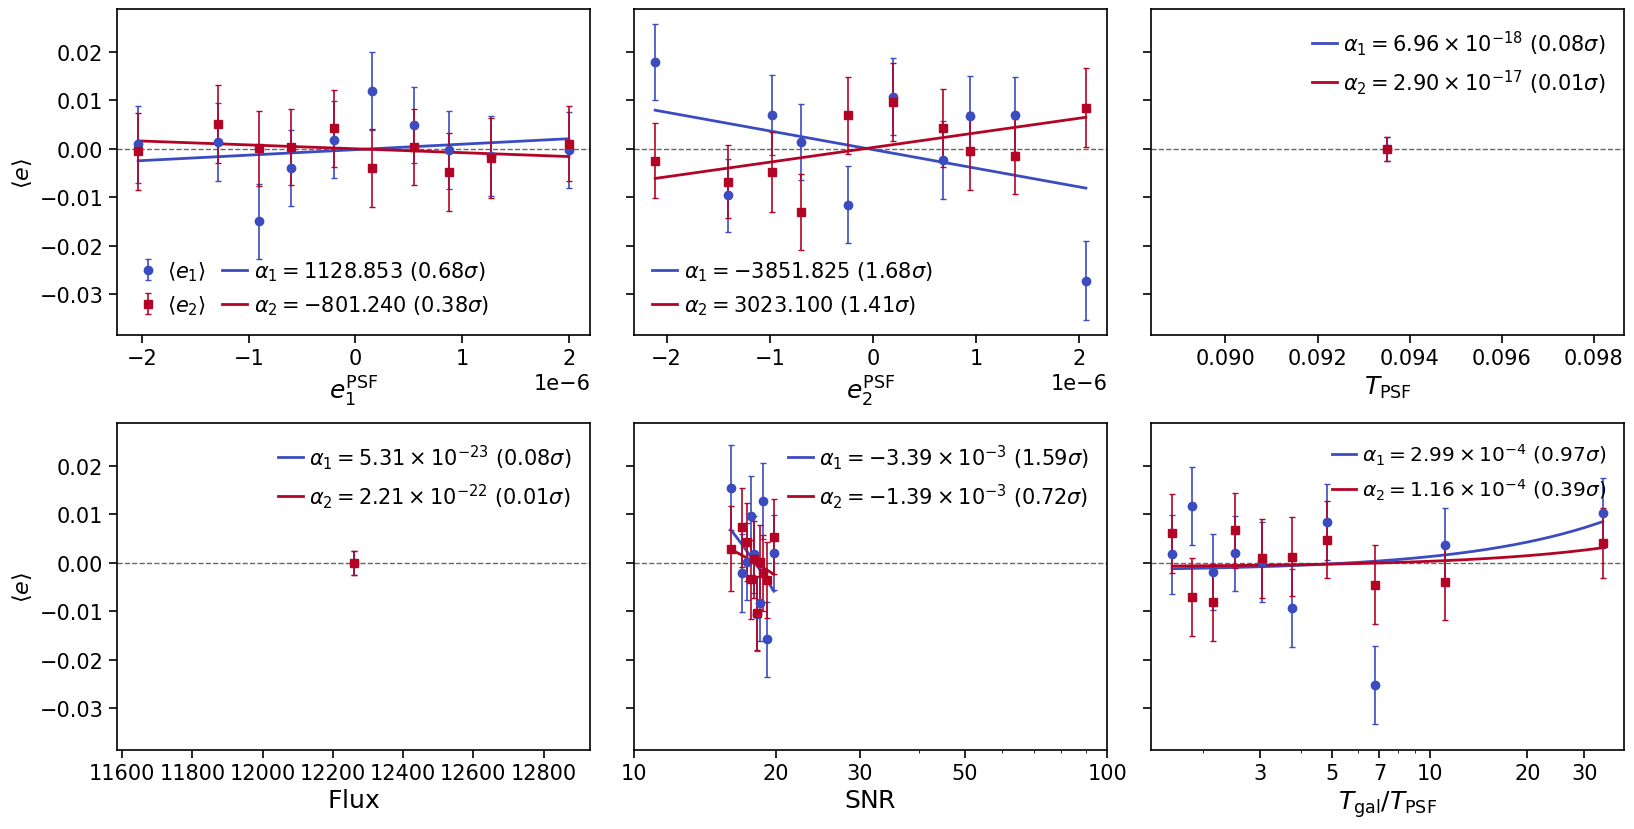

In [5]:
# -------------------------
# Matplotlib defaults
# -------------------------

mpl.rcParams.update({
    "figure.dpi": 100,
    "savefig.dpi": 400,
    "axes.labelsize": 18,
    "axes.titlesize": 16,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 15,
    "legend.title_fontsize": 13,
    "legend.handlelength": 1.2,
    "lines.linewidth": 2.2,
    "lines.markersize": 6,
    "axes.linewidth": 1.2,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
})

def percentile_binned_mean(
    x, y, nbin=20, min_count=10, weights=None,
    calibrate=False, calib=None, subtract_global_mean=True,
    x_center="median",
    error_type="sem",   # "sem" or "std"
):
    """
    Percentile-bin by x, compute <y> per bin and its uncertainty.
    Returns x_bin, y_bin, yerr_bin, counts, edges
    """
    x = np.asarray(x)
    y = np.asarray(y)

    m = np.isfinite(x) & np.isfinite(y)
    if weights is not None:
        w = np.asarray(weights)
        m &= np.isfinite(w)
    else:
        w = None

    if calibrate:
        if calib is None:
            raise ValueError("calib must be provided when calibrate=True")
        c = np.asarray(calib)
        m &= np.isfinite(c)
    else:
        c = None

    x = x[m]
    y = y[m]
    if w is not None:
        w = w[m]
    if c is not None:
        c = c[m]

    if subtract_global_mean:
        y = y - (np.average(y, weights=w) if w is not None else np.mean(y))

    edges = np.percentile(x, np.linspace(0, 100, nbin + 1))

    x_bin, y_bin, yerr_bin, counts = [], [], [], []

    for i in range(nbin):
        if i < nbin - 1:
            mbin = (x >= edges[i]) & (x < edges[i + 1])
        else:
            mbin = (x >= edges[i]) & (x <= edges[i + 1])

        n = int(np.sum(mbin))
        if n < min_count:
            print(f"[WARNING] number of points in bin {i}: {n}  didn't pass min count = {min_count}")
            continue

        xb = np.median(x[mbin]) if x_center == "median" else np.mean(x[mbin])
        yvals = y[mbin]

        if w is None:
            yb = np.mean(yvals)
            if error_type == "sem":
                yerr = np.std(yvals, ddof=1) / np.sqrt(n)
            else:
                yerr = np.std(yvals, ddof=1)
        else:
            wvals = w[mbin]
            yb = np.average(yvals, weights=wvals)
            yerr = np.sqrt(np.average((yvals - yb) ** 2, weights=wvals)) / np.sqrt(n)

        if calibrate:
            cvals = c[mbin]
            cb = np.median(cvals)
            if cb == 0:
                continue
            yb /= cb
            yerr /= cb

        x_bin.append(xb)
        y_bin.append(yb)
        yerr_bin.append(yerr)
        counts.append(n)

    return (
        np.asarray(x_bin),
        np.asarray(y_bin),
        np.asarray(yerr_bin),
        np.asarray(counts),
        edges,
    )


def slope_from_catalog(
    x, y, nbin=20, min_count=10, weights=None,
    calibrate=False, calib=None, subtract_global_mean=True,
    x_center="median",
    error_type="sem",
):
    x_bin, y_bin, yerr_bin, _, _ = percentile_binned_mean(
        x, y, nbin=nbin, min_count=min_count, weights=weights,
        calibrate=calibrate, calib=calib, subtract_global_mean=subtract_global_mean,
        x_center=x_center, error_type=error_type
    )

    w = 1.0 / yerr_bin**2
    alpha, beta = np.polyfit(x_bin, y_bin, 1, w=w)  # y = beta + alpha x
    return alpha, beta, x_bin, y_bin, yerr_bin


def make_panel_legend(ax, showe1e2_leg, loc=None, fontsize=None, columnspacing=0.8, handletextpad=0.3):
    handles, labels = ax.get_legend_handles_labels()

    if showe1e2_leg:
        order = [2, 3, 0, 1]
        ncol = 2
    else:
        order = [0, 1]
        ncol = 1

    ax.legend(
        [handles[i] for i in order],
        [labels[i] for i in order],
        ncol=ncol,
        frameon=False,
        columnspacing=columnspacing,
        handletextpad=handletextpad,
        loc=loc,
        fontsize=fontsize,
    )


def latex_sci(x, precision=2):
    """2.34e-3 -> 2.34 \\times 10^{-3}"""
    if x == 0:
        return "0"
    exp = int(np.floor(np.log10(abs(x))))
    mant = x / 10**exp
    return rf"{mant:.{precision}f}\times 10^{{{exp}}}"


def set_log_ticks_with_labels(ax, ticks=(10, 20, 30, 50, 100)):
    ax.set_xscale("log")
    ax.set_xticks(ticks)
    ax.get_xaxis().set_major_formatter(mticker.ScalarFormatter())
    ax.ticklabel_format(axis="x", style="plain")
    ax.xaxis.set_minor_locator(mticker.LogLocator(base=10, subs=np.arange(2, 10) * 0.1))
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())


color_e1 = "#3B4CC0"   # indigo
color_e2 = "#B40426"   # brick red


def make_panel(ax, x_psf, xlab, e1_gal, e2_gal, R11, R22, weights,
               nbin=10, min_count=20, njac=30, calibrate=False,
               x_log_scale=False, showe1e2_leg=False):
    
    calib_for_e1 = R11
    calib_for_e2 = R22
    
    alpha_full_1, beta_full_1, x_bin, y_bin_1, yerr_bin = slope_from_catalog(
        x=x_psf, y=e1_gal,
        nbin=nbin, min_count=min_count,
        weights=weights,
        calibrate=calibrate,
        calib=calib_for_e1,
        subtract_global_mean=True,
    )
    alpha_full_2, beta_full_2, _, y_bin_2, _ = slope_from_catalog(
        x=x_psf, y=e2_gal,
        nbin=nbin, min_count=min_count,
        weights=weights,
        calibrate=calibrate,
        calib=calib_for_e2,
        subtract_global_mean=True,
    )

    N = len(x_psf)
    jk_size = N // njac

    alpha_jk_1, alpha_jk_2 = [], []

    for i in range(njac):
        mask = np.ones(N, dtype=bool)
        mask[i * jk_size:(i + 1) * jk_size] = False

        a1, _, _, _, _ = slope_from_catalog(
            x_psf[mask], e1_gal[mask],
            nbin=nbin, min_count=min_count,
            weights=weights[mask],
            calibrate=calibrate,
            calib=calib_for_e1[mask],
            subtract_global_mean=True,
        )
        a2, _, _, _, _ = slope_from_catalog(
            x_psf[mask], e2_gal[mask],
            nbin=nbin, min_count=min_count,
            weights=weights[mask],
            calibrate=calibrate,
            calib=calib_for_e2[mask],
            subtract_global_mean=True,
        )

        alpha_jk_1.append(a1)
        alpha_jk_2.append(a2)

    alpha_jk_1 = np.asarray(alpha_jk_1)
    alpha_jk_2 = np.asarray(alpha_jk_2)

    alpha_mean_1 = np.mean(alpha_jk_1)
    alpha_err_1 = np.sqrt((njac - 1) / njac * np.sum((alpha_jk_1 - alpha_mean_1) ** 2))

    alpha_mean_2 = np.mean(alpha_jk_2)
    alpha_err_2 = np.sqrt((njac - 1) / njac * np.sum((alpha_jk_2 - alpha_mean_2) ** 2))

    xx = np.linspace(np.min(x_bin), np.max(x_bin), 200)
    yy_1 = beta_full_1 + alpha_full_1 * xx
    yy_2 = beta_full_2 + alpha_full_2 * xx

    ax.errorbar(
        x_bin, y_bin_1, yerr=yerr_bin, c=color_e1,
        fmt="o", capsize=2, elinewidth=1.2, label=r"$\langle e_1 \rangle$",
    )
    formatted_alpha = f"{alpha_full_1:.3f}" if abs(alpha_full_1) >= 1e-2 else latex_sci(alpha_full_1, precision=2)
    ax.plot(
        xx, yy_1, linewidth=2, c=color_e1,
        label=rf"$\alpha_1 = {formatted_alpha}\ ({(abs(alpha_mean_1)/alpha_err_1):.2f}\sigma)$",
    )

    ax.errorbar(
        x_bin, y_bin_2, yerr=yerr_bin, c=color_e2,
        fmt="s", capsize=2, elinewidth=1.2, label=r"$\langle e_2 \rangle$",
    )
    formatted_alpha = f"{alpha_full_2:.3f}" if abs(alpha_full_2) >= 1e-2 else latex_sci(alpha_full_2, precision=2)
    ax.plot(
        xx, yy_2, linewidth=2, c=color_e2,
        label=rf"$\alpha_2 = {formatted_alpha}\ ({(abs(alpha_mean_2)/alpha_err_2):.2f}\sigma)$",
    )

    if x_log_scale:
        if xlab == r"${\rm SNR}$":
            set_log_ticks_with_labels(ax, ticks=(10, 20, 30, 50, 100))
        elif xlab == r"$T_{\rm gal}/T_{\rm PSF}$":
            set_log_ticks_with_labels(ax, ticks=(3, 5, 7, 10, 20, 30))
        else:
            ax.set_xscale("log")

    ax.axhline(0, color="0.4", linestyle="--", linewidth=1, zorder=0)
    ax.set_xlabel(xlab)
    make_panel_legend(ax, showe1e2_leg)


# -------------------------
# Load data and apply selections
# -------------------------

NBIN = 10
CALIBRATE = False
MIN_COUNT = 20
njac = 30

# Quality and range selections
sel = (
    (data['catalog']['FLAGS'] == 0) &                          # No flags
    (data['catalog']['SNR'] > 10) &                            # SNR cut
    (data['catalog']['SIZE_RATIO'] > 1.5) &                    # Size ratio cut
    (data['catalog']['PSF_E1'] > -0.05) & (data['catalog']['PSF_E1'] < 0.05) &
    (data['catalog']['PSF_E2'] > -0.05) & (data['catalog']['PSF_E2'] < 0.05) &
    np.isfinite(data['catalog']['PSF_T']) &                    # Valid PSF measurements
    np.isfinite(data['catalog']['T_GAL']) &
    np.isfinite(data['catalog']['WEIGHT']) &                   # Valid weights
    (data['catalog']['WEIGHT'] > 0)                            # Positive weights
)

if np.sum(sel) == 0:
    raise ValueError("No galaxies passed selection! Check your cuts or FITS data.")

# -------------------------
# Pull arrays (apply selection)
# -------------------------
e1_psf = data['catalog']['PSF_E1'][sel]
e2_psf = data['catalog']['PSF_E2'][sel]
e_psf = np.hypot(e1_psf, e2_psf)

# Use uncalibrated predictions for PSF leakage analysis
e1_gal = data['catalog']['NN_G1'][sel]
e2_gal = data['catalog']['NN_G2'][sel]

T_gal = data['catalog']['T_GAL'][sel]
T_psf = data['catalog']['PSF_T'][sel]
snr = data['catalog']['SNR'][sel]
size_r = data['catalog']['SIZE_RATIO'][sel]
flux = data['catalog']['TRUE_FLUX'][sel]

R11 = data['catalog']['NN_R11'][sel]
R22 = data['catalog']['NN_R22'][sel]
weights = data['catalog']['WEIGHT'][sel]

# Renormalize weights after selection (important!)
weights = weights / np.sum(weights)

# -------------------------
# 6-panel figure
# -------------------------
fig, axes = plt.subplots(2, 3, figsize=(16.5, 8.4), sharey=True)
axes = axes.ravel()

x_list = [
    (e1_psf, r"$e_{1}^{\rm PSF}$"),
    (e2_psf, r"$e_{2}^{\rm PSF}$"),
    (T_psf,  r"$T_{\rm PSF}$"),
    (flux,   r"${\rm Flux}$"),          # Replaced MAG_AUTO with Flux
    (snr,    r"${\rm SNR}$"),
    (size_r, r"$T_{\rm gal}/T_{\rm PSF}$"),
]
log_labels = {r"${\rm SNR}$", r"$T_{\rm gal}/T_{\rm PSF}$"}

for ax, (x, xlab) in zip(axes, x_list):
    make_panel(
        ax,
        x_psf=x,
        xlab=xlab,
        e1_gal=e1_gal,
        e2_gal=e2_gal,
        R11=R11,
        R22=R22,
        weights=weights,
        nbin=NBIN,
        min_count=MIN_COUNT,
        njac=njac,
        calibrate=CALIBRATE,
        x_log_scale=(xlab in log_labels),
        showe1e2_leg=(ax is axes[0]),
    )

axes[0].set_ylabel(r"$\langle e \rangle$", fontsize=16)
axes[3].set_ylabel(r"$\langle e \rangle$", fontsize=16)

make_panel_legend(axes[5], showe1e2_leg=False, fontsize=14.5, loc="upper right")

plt.tight_layout()

plot_path = os.path.dirname(path)
outpath = os.path.join(plot_path, 'ShearNet_psf_leakage_6panel.pdf')
plt.savefig(outpath, bbox_inches="tight")
print(f"Saved to {outpath}")

plt.show()

[WARNING] number of points in bin 0: 0  didn't pass min count = 20
[WARNING] number of points in bin 1: 0  didn't pass min count = 20
[WARNING] number of points in bin 2: 0  didn't pass min count = 20
[WARNING] number of points in bin 3: 0  didn't pass min count = 20
[WARNING] number of points in bin 4: 0  didn't pass min count = 20
[WARNING] number of points in bin 5: 0  didn't pass min count = 20
[WARNING] number of points in bin 6: 0  didn't pass min count = 20
[WARNING] number of points in bin 7: 0  didn't pass min count = 20
[WARNING] number of points in bin 8: 0  didn't pass min count = 20
[WARNING] number of points in bin 0: 0  didn't pass min count = 20
[WARNING] number of points in bin 1: 0  didn't pass min count = 20
[WARNING] number of points in bin 2: 0  didn't pass min count = 20
[WARNING] number of points in bin 3: 0  didn't pass min count = 20
[WARNING] number of points in bin 4: 0  didn't pass min count = 20
[WARNING] number of points in bin 5: 0  didn't pass min count 

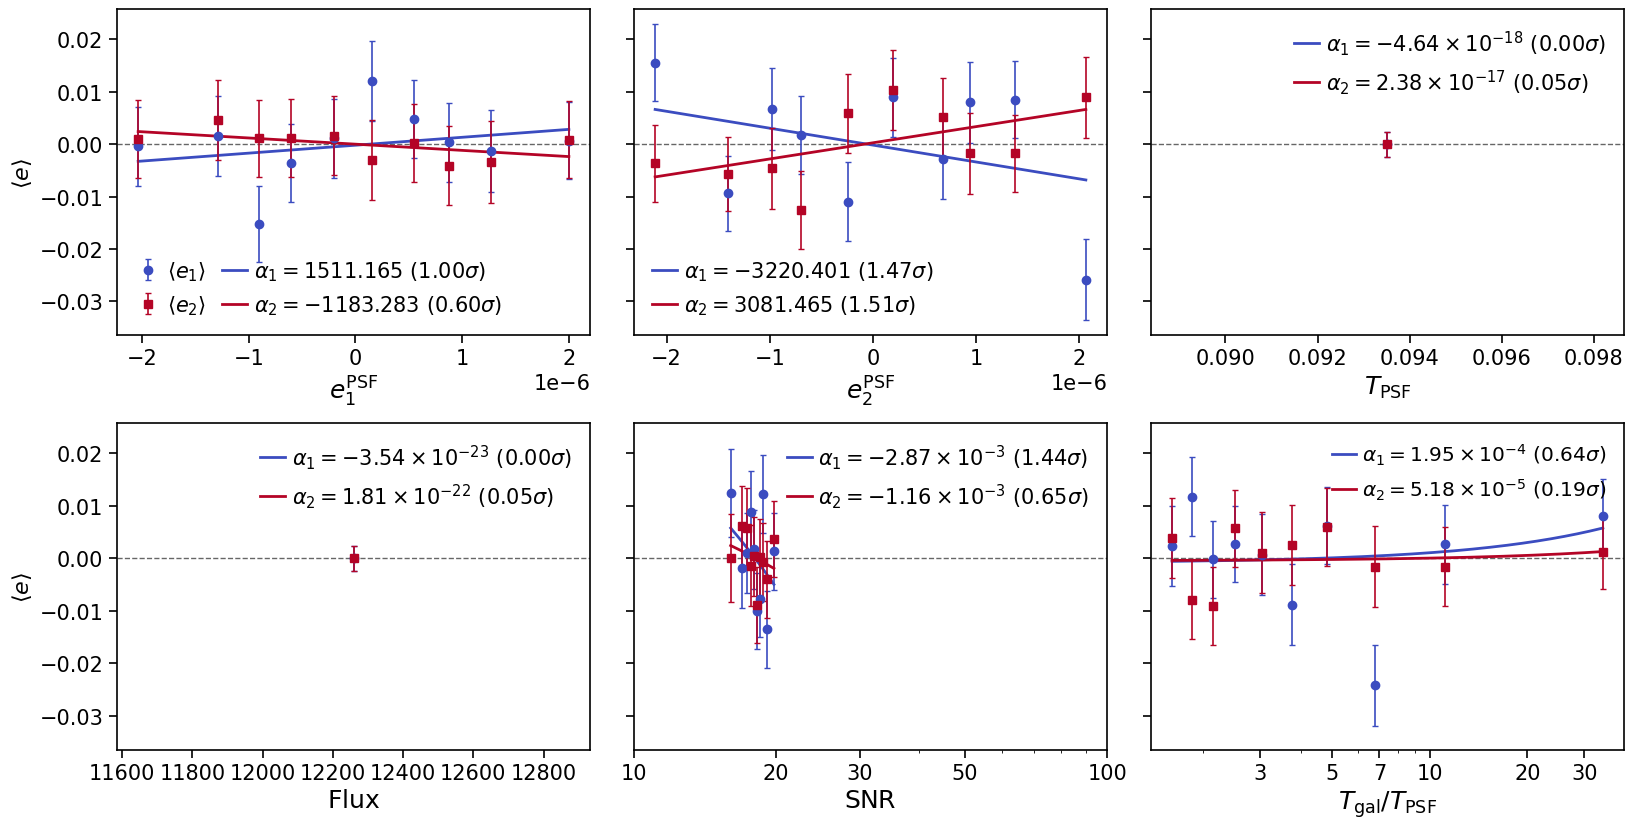

In [6]:
# -------------------------
# Matplotlib defaults
# -------------------------

mpl.rcParams.update({
    "figure.dpi": 100,
    "savefig.dpi": 400,
    "axes.labelsize": 18,
    "axes.titlesize": 16,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 15,
    "legend.title_fontsize": 13,
    "legend.handlelength": 1.2,
    "lines.linewidth": 2.2,
    "lines.markersize": 6,
    "axes.linewidth": 1.2,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
})

def percentile_binned_mean(
    x, y, nbin=20, min_count=10, weights=None,
    calibrate=False, calib=None, subtract_global_mean=True,
    x_center="median",
    error_type="sem",   # "sem" or "std"
):
    """
    Percentile-bin by x, compute <y> per bin and its uncertainty.
    Returns x_bin, y_bin, yerr_bin, counts, edges
    """
    x = np.asarray(x)
    y = np.asarray(y)

    m = np.isfinite(x) & np.isfinite(y)
    if weights is not None:
        w = np.asarray(weights)
        m &= np.isfinite(w)
    else:
        w = None

    if calibrate:
        if calib is None:
            raise ValueError("calib must be provided when calibrate=True")
        c = np.asarray(calib)
        m &= np.isfinite(c)
    else:
        c = None

    x = x[m]
    y = y[m]
    if w is not None:
        w = w[m]
    if c is not None:
        c = c[m]

    if subtract_global_mean:
        y = y - (np.average(y, weights=w) if w is not None else np.mean(y))

    edges = np.percentile(x, np.linspace(0, 100, nbin + 1))

    x_bin, y_bin, yerr_bin, counts = [], [], [], []

    for i in range(nbin):
        if i < nbin - 1:
            mbin = (x >= edges[i]) & (x < edges[i + 1])
        else:
            mbin = (x >= edges[i]) & (x <= edges[i + 1])

        n = int(np.sum(mbin))
        if n < min_count:
            print(f"[WARNING] number of points in bin {i}: {n}  didn't pass min count = {min_count}")
            continue

        xb = np.median(x[mbin]) if x_center == "median" else np.mean(x[mbin])
        yvals = y[mbin]

        if w is None:
            yb = np.mean(yvals)
            if error_type == "sem":
                yerr = np.std(yvals, ddof=1) / np.sqrt(n)
            else:
                yerr = np.std(yvals, ddof=1)
        else:
            wvals = w[mbin]
            yb = np.average(yvals, weights=wvals)
            yerr = np.sqrt(np.average((yvals - yb) ** 2, weights=wvals)) / np.sqrt(n)

        if calibrate:
            cvals = c[mbin]
            cb = np.median(cvals)
            if cb == 0:
                continue
            yb /= cb
            yerr /= cb

        x_bin.append(xb)
        y_bin.append(yb)
        yerr_bin.append(yerr)
        counts.append(n)

    return (
        np.asarray(x_bin),
        np.asarray(y_bin),
        np.asarray(yerr_bin),
        np.asarray(counts),
        edges,
    )


def slope_from_catalog(
    x, y, nbin=20, min_count=10, weights=None,
    calibrate=False, calib=None, subtract_global_mean=True,
    x_center="median",
    error_type="sem",
):
    x_bin, y_bin, yerr_bin, _, _ = percentile_binned_mean(
        x, y, nbin=nbin, min_count=min_count, weights=weights,
        calibrate=calibrate, calib=calib, subtract_global_mean=subtract_global_mean,
        x_center=x_center, error_type=error_type
    )

    w = 1.0 / yerr_bin**2
    alpha, beta = np.polyfit(x_bin, y_bin, 1, w=w)  # y = beta + alpha x
    return alpha, beta, x_bin, y_bin, yerr_bin


def make_panel_legend(ax, showe1e2_leg, loc=None, fontsize=None, columnspacing=0.8, handletextpad=0.3):
    handles, labels = ax.get_legend_handles_labels()

    if showe1e2_leg:
        order = [2, 3, 0, 1]
        ncol = 2
    else:
        order = [0, 1]
        ncol = 1

    ax.legend(
        [handles[i] for i in order],
        [labels[i] for i in order],
        ncol=ncol,
        frameon=False,
        columnspacing=columnspacing,
        handletextpad=handletextpad,
        loc=loc,
        fontsize=fontsize,
    )


def latex_sci(x, precision=2):
    """2.34e-3 -> 2.34 \\times 10^{-3}"""
    if x == 0:
        return "0"
    exp = int(np.floor(np.log10(abs(x))))
    mant = x / 10**exp
    return rf"{mant:.{precision}f}\times 10^{{{exp}}}"


def set_log_ticks_with_labels(ax, ticks=(10, 20, 30, 50, 100)):
    ax.set_xscale("log")
    ax.set_xticks(ticks)
    ax.get_xaxis().set_major_formatter(mticker.ScalarFormatter())
    ax.ticklabel_format(axis="x", style="plain")
    ax.xaxis.set_minor_locator(mticker.LogLocator(base=10, subs=np.arange(2, 10) * 0.1))
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())


color_e1 = "#3B4CC0"   # indigo
color_e2 = "#B40426"   # brick red


def make_panel(ax, x_psf, xlab, e1_gal, e2_gal, R11, R22, weights,
               nbin=10, min_count=20, njac=30, calibrate=False,
               x_log_scale=False, showe1e2_leg=False):
    
    calib_for_e1 = R11
    calib_for_e2 = R22
    
    alpha_full_1, beta_full_1, x_bin, y_bin_1, yerr_bin = slope_from_catalog(
        x=x_psf, y=e1_gal,
        nbin=nbin, min_count=min_count,
        weights=weights,
        calibrate=calibrate,
        calib=calib_for_e1,
        subtract_global_mean=True,
    )
    alpha_full_2, beta_full_2, _, y_bin_2, _ = slope_from_catalog(
        x=x_psf, y=e2_gal,
        nbin=nbin, min_count=min_count,
        weights=weights,
        calibrate=calibrate,
        calib=calib_for_e2,
        subtract_global_mean=True,
    )

    N = len(x_psf)
    jk_size = N // njac

    alpha_jk_1, alpha_jk_2 = [], []

    for i in range(njac):
        mask = np.ones(N, dtype=bool)
        mask[i * jk_size:(i + 1) * jk_size] = False

        a1, _, _, _, _ = slope_from_catalog(
            x_psf[mask], e1_gal[mask],
            nbin=nbin, min_count=min_count,
            weights=weights[mask],
            calibrate=calibrate,
            calib=calib_for_e1[mask],
            subtract_global_mean=True,
        )
        a2, _, _, _, _ = slope_from_catalog(
            x_psf[mask], e2_gal[mask],
            nbin=nbin, min_count=min_count,
            weights=weights[mask],
            calibrate=calibrate,
            calib=calib_for_e2[mask],
            subtract_global_mean=True,
        )

        alpha_jk_1.append(a1)
        alpha_jk_2.append(a2)

    alpha_jk_1 = np.asarray(alpha_jk_1)
    alpha_jk_2 = np.asarray(alpha_jk_2)

    alpha_mean_1 = np.mean(alpha_jk_1)
    alpha_err_1 = np.sqrt((njac - 1) / njac * np.sum((alpha_jk_1 - alpha_mean_1) ** 2))

    alpha_mean_2 = np.mean(alpha_jk_2)
    alpha_err_2 = np.sqrt((njac - 1) / njac * np.sum((alpha_jk_2 - alpha_mean_2) ** 2))

    xx = np.linspace(np.min(x_bin), np.max(x_bin), 200)
    yy_1 = beta_full_1 + alpha_full_1 * xx
    yy_2 = beta_full_2 + alpha_full_2 * xx

    ax.errorbar(
        x_bin, y_bin_1, yerr=yerr_bin, c=color_e1,
        fmt="o", capsize=2, elinewidth=1.2, label=r"$\langle e_1 \rangle$",
    )
    formatted_alpha = f"{alpha_full_1:.3f}" if abs(alpha_full_1) >= 1e-2 else latex_sci(alpha_full_1, precision=2)
    ax.plot(
        xx, yy_1, linewidth=2, c=color_e1,
        label=rf"$\alpha_1 = {formatted_alpha}\ ({(abs(alpha_mean_1)/alpha_err_1):.2f}\sigma)$",
    )

    ax.errorbar(
        x_bin, y_bin_2, yerr=yerr_bin, c=color_e2,
        fmt="s", capsize=2, elinewidth=1.2, label=r"$\langle e_2 \rangle$",
    )
    formatted_alpha = f"{alpha_full_2:.3f}" if abs(alpha_full_2) >= 1e-2 else latex_sci(alpha_full_2, precision=2)
    ax.plot(
        xx, yy_2, linewidth=2, c=color_e2,
        label=rf"$\alpha_2 = {formatted_alpha}\ ({(abs(alpha_mean_2)/alpha_err_2):.2f}\sigma)$",
    )

    if x_log_scale:
        if xlab == r"${\rm SNR}$":
            set_log_ticks_with_labels(ax, ticks=(10, 20, 30, 50, 100))
        elif xlab == r"$T_{\rm gal}/T_{\rm PSF}$":
            set_log_ticks_with_labels(ax, ticks=(3, 5, 7, 10, 20, 30))
        else:
            ax.set_xscale("log")

    ax.axhline(0, color="0.4", linestyle="--", linewidth=1, zorder=0)
    ax.set_xlabel(xlab)
    make_panel_legend(ax, showe1e2_leg)


# -------------------------
# Load data and apply selections
# -------------------------

NBIN = 10
CALIBRATE = False
MIN_COUNT = 20
njac = 30

# Quality and range selections
sel = (
    (data['catalog']['FLAGS'] == 0) &                          # No flags
    (data['catalog']['SNR'] > 10) &                            # SNR cut
    (data['catalog']['SIZE_RATIO'] > 1.5) &                    # Size ratio cut
    (data['catalog']['PSF_E1'] > -0.05) & (data['catalog']['PSF_E1'] < 0.05) &
    (data['catalog']['PSF_E2'] > -0.05) & (data['catalog']['PSF_E2'] < 0.05) &
    np.isfinite(data['catalog']['PSF_T']) &                    # Valid PSF measurements
    np.isfinite(data['catalog']['T_GAL']) &
    np.isfinite(data['catalog']['WEIGHT']) &                   # Valid weights
    (data['catalog']['WEIGHT'] > 0)                            # Positive weights
)

if np.sum(sel) == 0:
    raise ValueError("No galaxies passed selection! Check your cuts or FITS data.")

# -------------------------
# Pull arrays (apply selection)
# -------------------------
e1_psf = data['catalog']['PSF_E1'][sel]
e2_psf = data['catalog']['PSF_E2'][sel]
e_psf = np.hypot(e1_psf, e2_psf)

# Use uncalibrated predictions for PSF leakage analysis
e1_gal = data['catalog']['NGMIX_G1'][sel]
e2_gal = data['catalog']['NGMIX_G2'][sel]

T_gal = data['catalog']['T_GAL'][sel]
T_psf = data['catalog']['PSF_T'][sel]
snr = data['catalog']['SNR'][sel]
size_r = data['catalog']['SIZE_RATIO'][sel]
flux = data['catalog']['TRUE_FLUX'][sel]

R11 = data['catalog']['NGMIX_R11'][sel]
R22 = data['catalog']['NGMIX_R22'][sel]
weights = data['catalog']['WEIGHT'][sel]

# Renormalize weights after selection (important!)
weights = weights / np.sum(weights)

# -------------------------
# 6-panel figure
# -------------------------
fig, axes = plt.subplots(2, 3, figsize=(16.5, 8.4), sharey=True)
axes = axes.ravel()

x_list = [
    (e1_psf, r"$e_{1}^{\rm PSF}$"),
    (e2_psf, r"$e_{2}^{\rm PSF}$"),
    (T_psf,  r"$T_{\rm PSF}$"),
    (flux,   r"${\rm Flux}$"),          # Replaced MAG_AUTO with Flux
    (snr,    r"${\rm SNR}$"),
    (size_r, r"$T_{\rm gal}/T_{\rm PSF}$"),
]
log_labels = {r"${\rm SNR}$", r"$T_{\rm gal}/T_{\rm PSF}$"}

for ax, (x, xlab) in zip(axes, x_list):
    make_panel(
        ax,
        x_psf=x,
        xlab=xlab,
        e1_gal=e1_gal,
        e2_gal=e2_gal,
        R11=R11,
        R22=R22,
        weights=weights,
        nbin=NBIN,
        min_count=MIN_COUNT,
        njac=njac,
        calibrate=CALIBRATE,
        x_log_scale=(xlab in log_labels),
        showe1e2_leg=(ax is axes[0]),
    )

axes[0].set_ylabel(r"$\langle e \rangle$", fontsize=16)
axes[3].set_ylabel(r"$\langle e \rangle$", fontsize=16)

make_panel_legend(axes[5], showe1e2_leg=False, fontsize=14.5, loc="upper right")

plt.tight_layout()

plot_path = os.path.dirname(path)
outpath = os.path.join(plot_path, 'NGMix_psf_leakage_6panel.pdf')
plt.savefig(outpath, bbox_inches="tight")
print(f"Saved to {outpath}")

plt.show()